# Two-layer parameter sweep: is the graded ordering robust?

Follow-up task 3 from Jasper's message: the corrected result in `two_layer_consolidation.ipynb`
(`[8.53, 5.97, 6.24, 3.45, 3.46]` — primacy + recency blend, no single pattern monopolizing)
came from one arbitrary `(w_char_max, consolidation_rate)` pair. Before trusting the
qualitative shape, confirm it holds across a small grid of parameter choices.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

In [3]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
char_weight = 1.0

def make_update_fn(w_char_max, consolidation_rate):
    def update_two_layer(w_fast, w_char, retrieval_weights):
        w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast * retrieval_weights
        headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
        w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * headroom
        return w_fast, w_char
    return update_two_layer

def retrieve_two_layer(query, X, w_fast, w_char, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

In [4]:
def run_sweep_point(w_char_max, consolidation_rate, phase_len=400, phase_patterns=(0, 1, 2, 0), seed=0, dominant_prob=0.7):
    update_two_layer = make_update_fn(w_char_max, consolidation_rate)
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases

    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    fast_history = torch.zeros(n_steps, n_patterns)
    char_history = torch.zeros(n_steps, n_patterns)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)

    minor_prob = (1 - dominant_prob) / (n_patterns - 1)

    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob

        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

        retrieved, retrieval_weights = retrieve_two_layer(query, X, w_fast, w_char, beta=4.0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

        fast_history[step] = w_fast
        char_history[step] = w_char
        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()

    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {"fast": fast_history, "char": char_history, "queried": queried_idx_history,
            "won": won_idx_history, "phase_bounds": phase_bounds}

## Sweep grid

Baseline `(w_char_max=10, consolidation_rate=0.01)` plus 4 variants, one axis at a time:
low/high ceiling, low/high consolidation rate.

In [5]:
sweep_params = [
    ("baseline (10, 0.01)", 10.0, 0.01),
    ("low ceiling (5, 0.01)", 5.0, 0.01),
    ("high ceiling (20, 0.01)", 20.0, 0.01),
    ("slow consolidation (10, 0.005)", 10.0, 0.005),
    ("fast consolidation (10, 0.02)", 10.0, 0.02),
]

sweep_results = {}
for label, w_char_max, consolidation_rate in sweep_params:
    sweep_results[label] = run_sweep_point(w_char_max, consolidation_rate)
    final_char = sweep_results[label]["char"][-1]
    print(f"{label}: final w_char = {[round(v, 2) for v in final_char.tolist()]}")

baseline (10, 0.01): final w_char = [8.53, 5.97, 6.24, 3.45, 3.46]


low ceiling (5, 0.01): final w_char = [4.63, 4.03, 4.19, 3.11, 3.19]


high ceiling (20, 0.01): final w_char = [15.18, 5.84, 6.27, 3.31, 3.21]


slow consolidation (10, 0.005): final w_char = [7.2, 4.09, 4.21, 2.39, 2.39]


fast consolidation (10, 0.02): final w_char = [9.21, 7.8, 8.14, 5.35, 5.42]


In [6]:
phase_bounds_ref = [0, 400, 800, 1200, 1600]
phase_patterns_ref = [0, 1, 2, 0]

print("Peak w_char reached during each pattern's own dominant phase:")
for label, _, _ in sweep_params:
    char_history = sweep_results[label]["char"]
    peaks = []
    for p, dom in enumerate(phase_patterns_ref):
        lo, hi = phase_bounds_ref[p], phase_bounds_ref[p + 1]
        peaks.append(char_history[lo:hi, dom].max().item())
    print(f"  {label}: pattern-0(ph1)={peaks[0]:.2f} pattern-1(ph2)={peaks[1]:.2f} "
          f"pattern-2(ph3)={peaks[2]:.2f} pattern-0(ph4-return)={peaks[3]:.2f}")

Peak w_char reached during each pattern's own dominant phase:
  baseline (10, 0.01): pattern-0(ph1)=7.15 pattern-1(ph2)=5.06 pattern-2(ph3)=5.94 pattern-0(ph4-return)=8.53
  low ceiling (5, 0.01): pattern-0(ph1)=4.50 pattern-1(ph2)=4.14 pattern-2(ph3)=4.31 pattern-0(ph4-return)=4.63
  high ceiling (20, 0.01): pattern-0(ph1)=9.56 pattern-1(ph2)=4.58 pattern-2(ph3)=5.74 pattern-0(ph4-return)=15.18
  slow consolidation (10, 0.005): pattern-0(ph1)=4.87 pattern-1(ph2)=3.42 pattern-2(ph3)=3.94 pattern-0(ph4-return)=7.20
  fast consolidation (10, 0.02): pattern-0(ph1)=8.99 pattern-1(ph2)=7.68 pattern-2(ph3)=8.30 pattern-0(ph4-return)=9.21


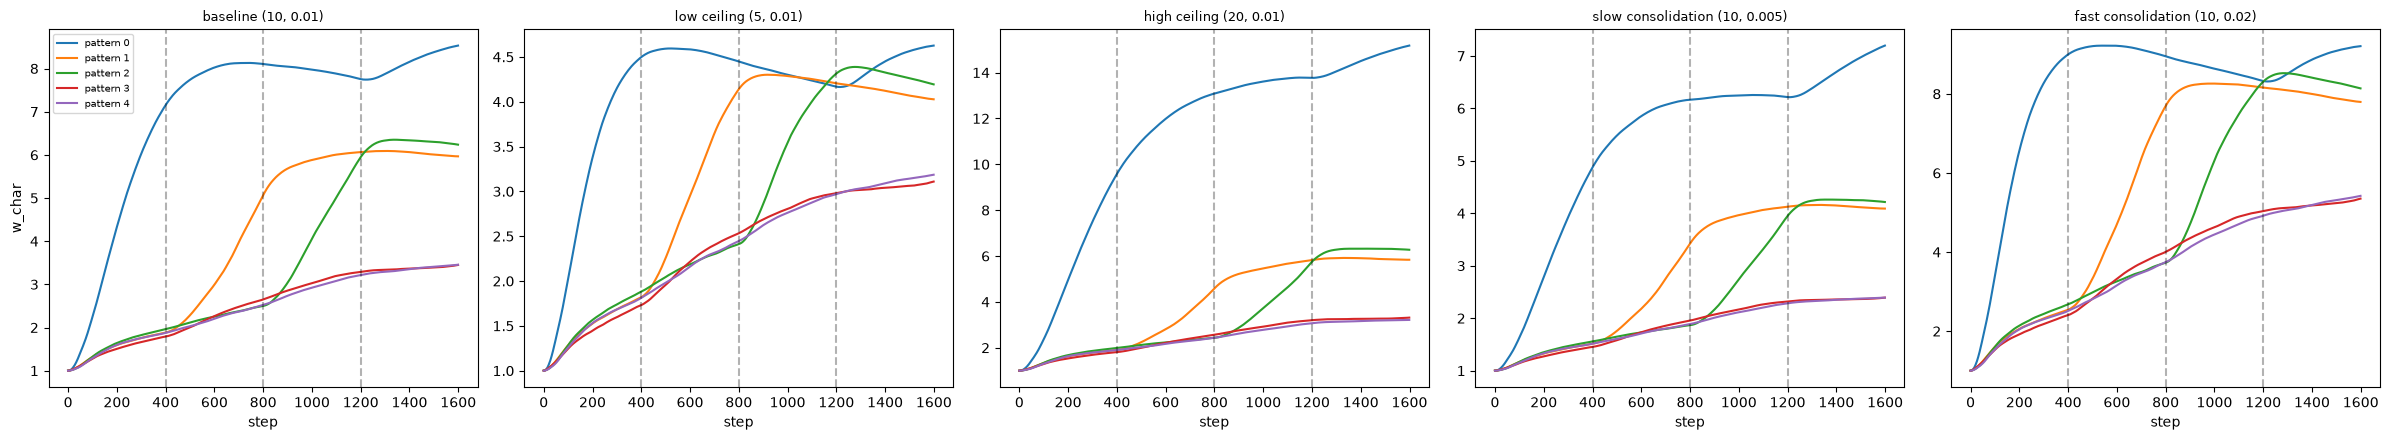

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=False)
for ax, (label, _, _) in zip(axes, sweep_params):
    char_history = sweep_results[label]["char"]
    for i in range(n_patterns):
        ax.plot(char_history[:, i].numpy(), label=f'pattern {i}')
    for pb in phase_bounds_ref[1:-1]:
        ax.axvline(x=pb, color='black', linestyle='--', alpha=0.3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('step')
axes[0].set_ylabel('w_char')
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.savefig('sweep_char_curves.png', dpi=100)
plt.show()

## Does the graded ordering (primacy + recency, no monopolization) hold across the grid?

Check two things per setting: (a) is any single pattern's final `w_char` more than, say,
5x the next-highest (monopolization), and (b) does the relative order roughly match
"pattern 0 (first + returned) >= pattern 2 (most recent dominant phase) > pattern 1 > never-dominant patterns"?

In [8]:
for label, _, _ in sweep_params:
    final_char = sweep_results[label]["char"][-1]
    sorted_vals, sorted_idx = torch.sort(final_char, descending=True)
    ratio_top_to_second = (sorted_vals[0] / sorted_vals[1]).item()
    monopolized = ratio_top_to_second > 5.0
    print(f"{label}: order (by final w_char, high->low) = {sorted_idx.tolist()}, "
          f"top/second ratio = {ratio_top_to_second:.2f}, monopolized = {monopolized}")

baseline (10, 0.01): order (by final w_char, high->low) = [0, 2, 1, 4, 3], top/second ratio = 1.37, monopolized = False
low ceiling (5, 0.01): order (by final w_char, high->low) = [0, 2, 1, 4, 3], top/second ratio = 1.10, monopolized = False
high ceiling (20, 0.01): order (by final w_char, high->low) = [0, 2, 1, 3, 4], top/second ratio = 2.42, monopolized = False
slow consolidation (10, 0.005): order (by final w_char, high->low) = [0, 2, 1, 4, 3], top/second ratio = 1.71, monopolized = False
fast consolidation (10, 0.02): order (by final w_char, high->low) = [0, 2, 1, 4, 3], top/second ratio = 1.13, monopolized = False
